# Feeding-Strategy Experiment — Combined Analysis (honors)

Merges two runs into one picture **without conflating incomparable arms**:

- **`exp_feeding_strategies.csv`** (exp 2): five **budget-matched** arms at full $P$ —
  `C_splitdata_fullcols`, `B_in_sqrt`, `B_in_dm`, `D_sqrt_fullP`, `D_dm_fullP`. **This file alone
  defines the primary feeding ranking**, because all five arms share the same per-SVM feature budget.
- **`exp_width_depth_scenarios.csv`** (exp 1): contributes the **`baseline_fullinput`** ($m{=}1$
  reference and full/full $m{>}1$) and **`featpart_fulldata`** (the $\Phi$-partition arm exp 2 did not run).

**Quarantined (NOT pooled):** exp 1's `input_subspace_sqrt`/`input_subspace_dm` ran at the **old $P/m$
budget** and at $m{=}1$ degenerate settings, and the file lacks a `full_data` flag to disambiguate
B vs D. They appear **only** in the budget-ablation table, never in the ranking.

Every row is tagged with `source`, `arm`, and `role` so no incomparable arms are silently mixed.
This guards the headline conclusion — *which feeding strategy is best, given $m{>}1$* — against the
budget/axis confounds.

In [ ]:
import os, re, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
pd.set_option("display.width",170); pd.set_option("display.max_columns",60)

P_FEED = "../results/1_exp_feeding_strategies.csv"
P_WD   = "../results/1_exp_width_depth_scenarios.csv"
if not os.path.exists(P_FEED):
    P_FEED="exp_feeding_strategies.csv"; P_WD="exp_width_depth_scenarios.csv"
OUT="tables"; os.makedirs(OUT,exist_ok=True)

## 1. Load both files (schema-robust) and tag provenance
The feeding CSV may be 16-col headerless or 23-col; the width_depth CSV is 16-col with a `split_id`
column. We normalise both, derive `arm`/`m`/`L` from the `model` string, and tag `source`.

In [2]:
S_FEED16=["exp_id","dataset","n_total","n_train","n_test","d","n_classes","model","kernel",
          "L","m","P","mean_cos_sim","acc","time_s","timestamp"]

def read_any(path):
    with open(path) as f: first=f.readline().strip().split(",")
    has_hdr = first[0]=="exp_id" and not first[-1][:4].isdigit()
    if has_hdr: return pd.read_csv(path)
    return pd.read_csv(path, names=S_FEED16)   # feeding fallback only

def prep(path, source):
    df=read_any(path); df.columns=[c.strip() for c in df.columns]
    df["source"]=source
    df["arm"]=df["model"].astype(str).str.replace(r"_m\d+_L\d+$","",regex=True)
    if "m" not in df or df["m"].isna().all(): df["m"]=df["model"].str.extract(r"_m(\d+)_L").astype(float)
    if "L" not in df or df["L"].isna().all(): df["L"]=df["model"].str.extract(r"_L(\d+)$").astype(float)
    for c in ["n_train","n_total","d","n_classes","m","L","P","acc","time_s","mean_cos_sim"]:
        if c in df: df[c]=pd.to_numeric(df[c],errors="coerce")
    if "mean_cos_sim" not in df: df["mean_cos_sim"]=np.nan
    df["cos"]=df["mean_cos_sim"]
    keep=["source","dataset","n_train","d","n_classes","arm","m","L","P","acc","cos","time_s"]
    return df[[c for c in keep if c in df.columns]]

feed=prep(P_FEED,"feeding"); wd=prep(P_WD,"width_depth")
df=pd.concat([feed,wd],ignore_index=True)
print("feeding rows:",len(feed)," width_depth rows:",len(wd))
print("arms (feeding):",sorted(feed.arm.unique()))
print("arms (width_depth):",sorted(wd.arm.unique()))
df.head()

feeding rows: 2104  width_depth rows: 1332
arms (feeding): ['B_in_dm', 'B_in_sqrt', 'C_splitdata_fullcols', 'D_dm_fullP', 'D_sqrt_fullP']
arms (width_depth): ['baseline_fullinput', 'featpart_fulldata', 'input_subspace_dm', 'input_subspace_sqrt']


,source,dataset,n_train,d,n_classes,arm,m,L,P,acc,cos,time_s
0,feeding,HIGGS,1000,28,2,C_splitdata_fullcols,1,1,1000,0.5737,NaN,0.26
1,feeding,HIGGS,1000,28,2,C_splitdata_fullcols,1,1,1000,0.5768,NaN,0.25
2,feeding,HIGGS,1000,28,2,C_splitdata_fullcols,1,1,1000,0.5709,NaN,0.27
3,feeding,HIGGS,1000,28,2,C_splitdata_fullcols,1,2,1000,0.5739,NaN,0.28
4,feeding,HIGGS,1000,28,2,C_splitdata_fullcols,1,2,1000,0.5757,NaN,0.23


## 2. Assign role — the safety mechanism
`ranking` = the five budget-matched feeding arms from exp 2 (primary question). `enrich` = exp 1's
baseline + featpart. `ablation_old` = exp 1's old-$P/m$ subspace arms (quarantined). Anything else →
`other` and is excluded from all summary tables.

In [3]:
FEEDING_ARMS={"C_splitdata_fullcols","B_in_sqrt","B_in_dm","D_sqrt_fullP","D_dm_fullP"}
ENRICH_ARMS={"baseline_fullinput","featpart_fulldata"}
ABLATION_OLD={"input_subspace_sqrt","input_subspace_dm"}
def role(r):
    if r.source=="feeding" and r.arm in FEEDING_ARMS: return "ranking"
    if r.source=="width_depth" and r.arm in ENRICH_ARMS: return "enrich"
    if r.source=="width_depth" and r.arm in ABLATION_OLD: return "ablation_old"
    return "other"
df["role"]=df.apply(role,axis=1)
print(df.role.value_counts().to_string())
# nice labels
NICE={"C_splitdata_fullcols":"C (split data)","B_in_sqrt":"B (cols √d)","B_in_dm":"B (cols d/m)",
      "D_sqrt_fullP":"D (both √d)","D_dm_fullP":"D (both d/m)",
      "baseline_fullinput":"A (full, baseline)","featpart_fulldata":"B-Φ (feat partition)"}
df["label"]=df.arm.map(lambda a: NICE.get(a,a))

role
ranking         2104
ablation_old     783
enrich           549


## 3. Aggregate to mean ± std over seeds (best L per cell)

In [4]:
def agg(sub):
    g=(sub.groupby(["dataset","label","arm","m","L","n_train"])
         .agg(acc_mean=("acc","mean"),acc_std=("acc","std"),cos=("cos","mean"),
              t=("time_s","mean"),seeds=("acc","size")).reset_index())
    g["acc_std"]=g.acc_std.fillna(0.0)
    bestL=g.sort_values("acc_mean",ascending=False).groupby(
        ["dataset","label","arm","m","n_train"]).first().reset_index()
    return g, bestL
cell, bestL = agg(df[df.role.isin(["ranking","enrich"])])
print(len(cell),"cells /",len(bestL),"best-L rows")
bestL.head()

769 cells / 324 best-L rows


,dataset,label,arm,m,n_train,L,acc_mean,acc_std,cos,t,seeds
0,CoverType,"A (full, baseline)",baseline_fullinput,1,1000,1,0.665333,0.002511,NaN,1.073333,3
1,CoverType,"A (full, baseline)",baseline_fullinput,1,5000,2,0.740667,0.004508,NaN,9.080000,3
2,CoverType,"A (full, baseline)",baseline_fullinput,1,10000,3,0.768267,0.004517,NaN,25.596667,3
3,CoverType,"A (full, baseline)",baseline_fullinput,1,50000,3,0.795533,0.001401,NaN,150.556667,3
4,CoverType,"A (full, baseline)",baseline_fullinput,1,100000,3,0.797900,0.001153,NaN,292.500000,3


## 4. PRIMARY — feeding ranking at $m=10$ (ranking arms only)
Uses **only** the budget-matched exp 2 arms. A win counts only if the margin exceeds the seed spread.

In [5]:
rk=bestL[(bestL.arm.isin(FEEDING_ARMS))&(bestL.m==10)].copy()
rk["rank"]=rk.groupby(["dataset","n_train"]).acc_mean.rank(ascending=False)
ranking=rk.groupby("label")["rank"].agg(mean_rank="mean",cells="size").sort_values("mean_rank").round(2)
print("Overall feeding ranking @ m=10 (budget-matched arms only):"); display(ranking)

print("\nBest feeder per dataset×n (m=10):")
for (ds,n),g in rk.groupby(["dataset","n_train"]):
    g=g.sort_values("acc_mean",ascending=False)
    b=g.iloc[0]; margin=b.acc_mean-(g.iloc[1].acc_mean if len(g)>1 else np.nan)
    sig="" if (len(g)<2 or margin>b.acc_std) else "  (within seed band)"
    print(f"  {ds:10s} n={int(n):>6} -> {b.label:18s} {b.acc_mean:.4f}±{b.acc_std:.4f}{sig}")

Overall feeding ranking @ m=10 (budget-matched arms only):


,mean_rank,cells
label,,
C (split data),1.40,15
B (cols d/m),1.75,24
B (cols √d),2.60,25
D (both d/m),3.46,13
D (both √d),4.69,13



Best feeder per dataset×n (m=10):
  CoverType  n=  1000 -> B (cols d/m)       0.6720±0.0056
  CoverType  n=  5000 -> C (split data)     0.7365±0.0038
  CoverType  n= 10000 -> C (split data)     0.7610±0.0044  (within seed band)
  CoverType  n= 50000 -> C (split data)     0.7946±0.0030
  Digits8x8  n=   500 -> B (cols d/m)       0.9567±0.0083
  Digits8x8  n=  1000 -> B (cols d/m)       0.9620±0.0072
  Digits8x8  n=  1297 -> B (cols d/m)       0.9593±0.0153  (within seed band)
  HIGGS      n=  1000 -> B (cols d/m)       0.5947±0.0029
  HIGGS      n=  5000 -> C (split data)     0.6387±0.0020
  HIGGS      n= 10000 -> C (split data)     0.6445±0.0059
  HIGGS      n= 50000 -> C (split data)     0.6703±0.0022
  HIGGS      n=100000 -> C (split data)     0.6726±0.0064
  HIGGS      n=200000 -> C (split data)     0.6767±0.0052
  MNIST      n=  1000 -> B (cols d/m)       0.8928±0.0046
  MNIST      n=  5000 -> B (cols d/m)       0.9430±0.0033
  MNIST      n= 10000 -> B (cols d/m)       0.9541±0.00

## 5. Per-dataset feeding tables @ m=10 (mean ± std)
Ranking arms + baseline (m=1) and B-Φ shown for context, but the ranking in §4 is the ranking arms only.

In [6]:
def show(ds,m=10):
    s=bestL[(bestL.dataset==ds)&(bestL.m==m)]
    pm=s.pivot_table(index="label",columns="n_train",values="acc_mean")
    ps=s.pivot_table(index="label",columns="n_train",values="acc_std")
    out=pm.astype(object).copy()
    for a in pm.index:
        for n in pm.columns:
            if pd.notna(pm.loc[a,n]): out.loc[a,n]=f"{pm.loc[a,n]:.4f} ± {ps.loc[a,n]:.4f}"
    return out
for ds in sorted(bestL.dataset.unique()):
    print(f"\n=== {ds}  (m=10) ==="); display(show(ds))


=== CoverType  (m=10) ===


n_train,1000,5000,10000,50000,100000
label,,,,,
B (cols d/m),0.6720 ± 0.0056,0.7286 ± 0.0026,0.7570 ± 0.0042,NaN,NaN
B (cols √d),0.6347 ± 0.0363,0.6975 ± 0.0236,0.7256 ± 0.0206,0.7513 ± 0.0158,NaN
B-Φ (feat partition),0.6811 ± 0.0086,0.7390 ± 0.0009,0.7557 ± 0.0045,0.7610 ± 0.0021,0.7584 ± 0.0050
C (split data),NaN,0.7365 ± 0.0038,0.7610 ± 0.0044,0.7946 ± 0.0030,NaN
D (both d/m),NaN,0.7178 ± 0.0033,0.7302 ± 0.0038,NaN,NaN
D (both √d),NaN,0.6822 ± 0.0331,0.7010 ± 0.0320,NaN,NaN



=== Digits8x8  (m=10) ===


n_train,500,1000,1297
label,,,
B (cols d/m),0.9567 ± 0.0083,0.9620 ± 0.0072,0.9593 ± 0.0153
B (cols √d),0.9287 ± 0.0162,0.9447 ± 0.0064,0.9453 ± 0.0153



=== HIGGS  (m=10) ===


...

n_train,1000,5000,10000,50000
label,,,,
B (cols d/m),0.8928 ± 0.0046,0.9430 ± 0.0033,0.9541 ± 0.0008,0.9709 ± 0.0010
B (cols √d),0.8276 ± 0.0220,0.8979 ± 0.0050,0.9165 ± 0.0051,0.9388 ± 0.0039
B-Φ (feat partition),0.8535 ± 0.0043,0.9030 ± 0.0008,0.9185 ± 0.0009,0.9297 ± 0.0028
C (split data),NaN,0.9134 ± 0.0019,0.9282 ± 0.0038,0.9490 ± 0.0006
D (both d/m),NaN,0.9086 ± 0.0013,0.9316 ± 0.0023,NaN
D (both √d),NaN,0.8800 ± 0.0062,0.8999 ± 0.0046,NaN



=== Optdigits  (m=10) ===


n_train,500,1000,2000,3823
label,,,,
B (cols d/m),0.9345 ± 0.0091,0.9496 ± 0.0072,0.9647 ± 0.0032,0.9739 ± 0.0037
B (cols √d),0.9075 ± 0.0126,0.9267 ± 0.0098,0.9439 ± 0.0161,0.9549 ± 0.0054
C (split data),NaN,NaN,0.9757 ± 0.0054,0.9816 ± 0.0029
D (both d/m),NaN,NaN,0.9615 ± 0.0018,0.9659 ± 0.0014
D (both √d),NaN,NaN,0.9380 ± 0.0049,0.9605 ± 0.0052



=== Satimage  (m=10) ===


n_train,500,1000,2000,4435
label,,,,
B (cols d/m),0.8593 ± 0.0094,0.8795 ± 0.0059,0.8815 ± 0.0114,0.8969 ± 0.0035
B (cols √d),0.8541 ± 0.0139,0.8818 ± 0.0102,0.8922 ± 0.0187,0.9069 ± 0.0098
C (split data),NaN,NaN,0.8893 ± 0.0106,0.9025 ± 0.0044
D (both d/m),NaN,NaN,0.8888 ± 0.0114,0.8930 ± 0.0031
D (both √d),NaN,NaN,0.8852 ± 0.0101,0.8979 ± 0.0012


## 6. SECONDARY — $m>1$ vs the $m=1$ baseline
Baseline = exp 1 `baseline_fullinput` at $m{=}1$ (the proper full/full reference). Gain flagged
significant when it exceeds the best arm's seed std.

In [7]:
rows=[]
for (ds,n),g in bestL.groupby(["dataset","n_train"]):
    base=g[(g.arm=="baseline_fullinput")&(g.m==1)]
    if base.empty: base=g[g.m==1]              # fallback
    bg=g[(g.arm.isin(FEEDING_ARMS))&(g.m>1)]
    if base.empty or bg.empty: continue
    b=base.acc_mean.max(); top=bg.loc[bg.acc_mean.idxmax()]
    rows.append(dict(dataset=ds,n=int(n),m1=round(b,4),best=round(top.acc_mean,4),
        std=round(top.acc_std,4),m=int(top.m),arm=top.label,gain=round(top.acc_mean-b,4),
        sig=bool(top.acc_mean-b>top.acc_std)))
gain=pd.DataFrame(rows); display(gain)
print("significant gains:",int(gain.sig.sum()),"/",len(gain))

,dataset,n,m1,best,std,m,arm,gain,sig
0,CoverType,1000,0.6653,0.6919,0.0058,50,B (cols d/m),0.0265,True
1,CoverType,5000,0.7407,0.7618,0.0066,50,B (cols √d),0.0212,True
2,CoverType,10000,0.7683,0.8007,0.0045,50,B (cols √d),0.0324,True
3,CoverType,50000,0.7955,0.7946,0.0030,10,C (split data),-0.0009,False
4,Digits8x8,500,0.9727,0.9720,0.0080,50,B (cols √d),-0.0007,False
5,Digits8x8,1000,0.9793,0.9807,0.0031,50,B (cols √d),0.0013,False
6,Digits8x8,1297,0.9807,0.9820,0.0040,50,B (cols √d),0.0013,False
7,HIGGS,1000,0.5738,0.6204,0.0071,50,B (cols √d),0.0465,True
8,HIGGS,5000,0.6154,0.6502,0.0022,50,B (cols √d),0.0348,True
9,HIGGS,10000,0.6358,0.6598,0.0046,50,B (cols √d),0.0241,True


significant gains: 16 / 25


## 7. SECONDARY — depth (L1→L2) and decorrelation

In [8]:
# depth
d2=cell[(cell.arm.isin(FEEDING_ARMS))&(cell.m>1)].pivot_table(index=['dataset','label','m','n_train'],columns='L',values='acc_mean')
if set([1,2]).issubset(d2.columns):
    d2=d2.dropna(subset=[1,2]); d2['dL']=d2[2]-d2[1]
    display(d2.groupby('dataset')['dL'].agg(['mean','median','count']).round(4))
# decorrelation — use FEEDING rows (width_depth has no cos)
fdf=df[(df.source=='feeding')&(df.m>1)&df.cos.notna()]
fc=fdf.groupby(['dataset','arm','m','L','n_train']).agg(acc=('acc','mean'),cos=('cos','mean')).reset_index()
print('corr(cos_sim, acc) by dataset:')
for ds,g in fc.groupby('dataset'):
    if len(g)>3: print(f'  {ds:10s} r={g.cos.corr(g.acc):+.3f} (n={len(g)})')


,mean,median,count
dataset,,,
CoverType,0.0125,0.0104,24
Digits8x8,0.0141,0.0067,12
HIGGS,0.0007,0.0009,39
MNIST,0.0012,0.0019,26
Optdigits,0.0066,0.0028,22
Satimage,0.0064,0.0049,18


corr(cos_sim, acc) by dataset:


## 8. ABLATION (quarantined) — feature budget: old $P/m$ vs new full $P$
This is the *only* place exp 1's `input_subspace_*` arms appear, compared against exp 2's full-$P$
`D_*` arms **at $m>1$**. It measures how much the per-SVM feature budget matters — the empirical
justification for budget-matching. **Not part of the feeding ranking.**

In [9]:
abm={"input_subspace_sqrt":("D (√d)","old P/m"),"input_subspace_dm":("D (d/m)","old P/m"),
     "D_sqrt_fullP":("D (√d)","full P"),"D_dm_fullP":("D (d/m)","full P")}
ab=df[df.arm.isin(abm)].copy()
ab=ab[ab.m>1]
ab["subspace"]=ab.arm.map(lambda a:abm[a][0]); ab["budget"]=ab.arm.map(lambda a:abm[a][1])
abp=ab.groupby(["dataset","subspace","m","budget"]).acc.agg(
    lambda s:f"{s.mean():.4f} ± {s.std():.4f}" if len(s)>1 else f"{s.mean():.4f} ± 0.0000")
display(abp.unstack("budget"))
print("Reportable: at fixed (dataset, subspace, m), full P vs P/m isolates the budget effect.")

budget                          full P          old P/m
dataset   subspace m                                   
CoverType D (d/m)  10  0.7204 ± 0.0080  0.7253 ± 0.0272
                   50  0.7316 ± 0.0133  0.7275 ± 0.0317
          D (√d)   10  0.6892 ± 0.0286  0.6978 ± 0.0370
                   50  0.7526 ± 0.0055  0.7428 ± 0.0328
HIGGS     D (d/m)  10  0.6296 ± 0.0185  0.6382 ± 0.0194
          D (√d)   10  0.6146 ± 0.0254  0.6253 ± 0.0239
                   50  0.6544 ± 0.0177  0.6582 ± 0.0209
MNIST     D (d/m)  10  0.9186 ± 0.0127  0.9029 ± 0.0328
                   50  0.9062 ± 0.0058  0.8867 ± 0.0472
          D (√d)   10  0.8779 ± 0.0192  0.8707 ± 0.0457
                   50  0.9186 ± 0.0050  0.8801 ± 0.0464
Optdigits D (d/m)  10  0.9597 ± 0.0088              NaN
          D (√d)   10  0.9432 ± 0.0127              NaN
Satimage  D (d/m)  10  0.8872 ± 0.0081              NaN
          D (√d)   10  0.8898 ± 0.0107              NaN

Reportable: at fixed (dataset, subspace, m), full P vs P/m isolates the budget effect.


## 9. Write LaTeX tables → `tables/`
Focused (ranking, per-dataset mean±std, m>1 gain, depth, decorrelation) + appendix (full grid) +
the budget-ablation table. All `booktabs`.

In [10]:
def esc(s): return str(s).replace("_",r"\_")
def tbl(body,cap,lab,spec,hdr):
    return ("\\begin{table}[ht]\n\\centering\\small\n\\begin{tabular}{%s}\n\\toprule\n%s \\\\\n\\midrule\n%s\\bottomrule\n\\end{tabular}\n\\caption{%s}\n\\label{%s}\n\\end{table}\n"%(spec,hdr,body,cap,lab))
DSORD=["HIGGS","CoverType","MNIST","Optdigits","Satimage","Digits8x8"]

# ranking
body="".join(f"{esc(a)} & {r.mean_rank:.2f} & {int(r.cells)} \\\\\n" for a,r in ranking.iterrows())
open(f"{OUT}/feeding_ranking_m10.tex","w").write(tbl(body,
  "Feeding-strategy ranking at $m=10$ (budget-matched arms; lower mean rank better).",
  "tab:feeding_ranking","lcc","Feeding strategy & Mean rank & Cells"))

# per dataset mean±std (ranking arms only, bold best per column)
blocks=[]
for ds in [d for d in DSORD if d in bestL.dataset.unique()]:
    s=bestL[(bestL.dataset==ds)&(bestL.m==10)&(bestL.arm.isin(FEEDING_ARMS))]
    if s.empty: continue
    ns=sorted(s.n_train.unique())
    pm=s.pivot_table(index="label",columns="n_train",values="acc_mean")
    ps=s.pivot_table(index="label",columns="n_train",values="acc_std")
    best={n:pm[n].idxmax() for n in ns if pm[n].notna().any()}
    hdr="Arm & "+" & ".join(f"$n{{=}}{int(n)}$" for n in ns)
    bd=""
    for a in pm.index:
        cs=[]
        for n in ns:
            if pd.notna(pm.loc[a,n]):
                c=f"{pm.loc[a,n]:.4f}\\,$\\pm$\\,{ps.loc[a,n]:.4f}"
                if a==best.get(n): c=f"\\textbf{{{c}}}"
            else: c=""
            cs.append(c)
        bd+=f"{esc(a)} & "+" & ".join(cs)+" \\\\\n"
    blocks.append(tbl(bd,
      f"Feeding strategies on {esc(ds)} at $m=10$ (mean\\,$\\pm$\\,std; best per column bold).",
      f"tab:feed_{ds.lower()}","l"+"c"*len(ns),hdr))
open(f"{OUT}/feeding_per_dataset_m10.tex","w").write("\n".join(blocks))

# m gain
bd=""
for _,r in gain.sort_values(["dataset","n"]).iterrows():
    star="$^\\dagger$" if r.sig else ""
    bd+=(f"{esc(r.dataset)} & {int(r.n)} & {r.m1:.4f} & {r.best:.4f}\\,$\\pm$\\,{r['std']:.4f} & "
         f"{int(r.m)} & {esc(r.arm)} & {r.gain:+.4f}{star} \\\\\n")
open(f"{OUT}/m_gain.tex","w").write(tbl(bd,
  "Best $m>1$ feeding arm vs.\\ the $m=1$ baseline (mean\\,$\\pm$\\,std). "
  "$^\\dagger$: gain exceeds seed std.","tab:mgain","llcclll",
  "Dataset & $n$ & $m{=}1$ & best $m{>}1$ & $m$ & arm & gain"))

# budget ablation
au=abp.unstack("budget")
cols=list(au.columns)
hdr="Dataset & Subspace & $m$ & "+" & ".join(esc(c) for c in cols)
bd=""
for idx,row in au.iterrows():
    ds,ss,m=idx
    vals=" & ".join(("" if pd.isna(row[c]) else str(row[c])) for c in cols)
    bd+=f"{esc(ds)} & {esc(ss)} & {int(m)} & {vals} \\\\\n"
open(f"{OUT}/budget_ablation.tex","w").write(tbl(bd,
  "Feature-budget ablation ($m>1$): old $P/m$ vs full $P$ per SVM for the data-split $D$ arms. "
  "Quarantined from the feeding ranking.","tab:budget","lll"+"c"*len(cols),hdr))

# appendix (ranking+enrich full grid)
for ds in [d for d in DSORD if d in cell.dataset.unique()]:
    s=cell[cell.dataset==ds].sort_values(["n_train","label","m","L"])
    bd=""
    for _,r in s.iterrows():
        bd+=(f"{int(r.n_train)} & {esc(r.label)} & {int(r.m)} & {int(r.L)} & "
             f"{r.acc_mean:.4f}\\,$\\pm$\\,{r.acc_std:.4f} & "
             f"{('' if pd.isna(r.cos) else f'{r.cos:.3f}')} & {r.t:.1f} \\\\\n")
    open(f"{OUT}/appendix_{ds.lower()}.tex","w").write(tbl(bd,
      f"Complete results on {esc(ds)} (mean\\,$\\pm$\\,std over seeds; ranking + enrichment arms).",
      f"tab:app_{ds.lower()}","rlrrccr","$n$ & Arm & $m$ & $L$ & test acc & cos & t(s)"))
print("written:",sorted(os.listdir(OUT)))

written: ['appendix_covertype.tex', 'appendix_digits8x8.tex', 'appendix_higgs.tex', 'appendix_mnist.tex', 'appendix_optdigits.tex', 'appendix_satimage.tex', 'budget_ablation.tex', 'feeding_per_dataset_m10.tex', 'feeding_ranking_m10.tex', 'm_gain.tex']


## 10. Proposed additional insights (from data you already have)

1. **Width sweep $m\in\{1,10,50\}$ as a curve** (exp 1 has $m{>}1$ full/full; exp 2 has all arms):
   plot accuracy vs $m$ per dataset to show where width saturates — feeds directly into the
   later width/depth experiment.
2. **B-Φ (feature partition) vs B-input (column subset):** exp 1's `featpart_fulldata` vs exp 2's
   `B_in_*` isolates *variable-blindness* (input subset) from *random-direction* partition (Φ subset)
   at matched $m$ — a clean mechanistic comparison.
3. **Depth $\times$ width interaction:** does $L{=}2$ help more at small or large $m$? Pivot
   $\Delta_L$ by $m$.
4. **Time–accuracy Pareto front:** plot mean accuracy vs mean train time per arm; argue the
   scalability story (which arms buy accuracy cheaply).
5. **Per-dataset $d$ vs best arm:** regress "B wins vs C wins" against dimensionality $d$ to make
   the regime boundary quantitative rather than anecdotal.

Each is a few lines on the merged frame; ask and I'll add the cells.

## 11. Writeup caveats
- **Primary ranking uses budget-matched exp 2 arms only.** exp 1's `input_subspace_*` are old-$P/m$
  and appear solely in the budget ablation (§8).
- **m=50 entries in `m_gain.tex`** reflect a column-budget artifact for B$_{d/m}$ on low-$d$; treat as
  an $m$-sweep hook, not a feeding verdict.
- **CoverType** is incomplete (stopped at $n{=}50$k) — note in captions.
- exp 1 and exp 2 share $P=1000$, arc-cosine deg 1, block/final $C$, 3 seeds — verify before pooling
  baseline/featpart, and state it.

## 12. Plots — visual confirmation of each claim

Each figure backs one claim and is saved to `figures/` for `\includegraphics` in Overleaf. Provenance discipline matches the tables: ranking/regime use budget-matched feeding arms at $m=10$; $m=50$ gets its own caveat figure; decorrelation uses feeding rows only.

In [11]:
import os, matplotlib.pyplot as plt
FIG="figures"; os.makedirs(FIG, exist_ok=True)
plt.rcParams.update({"figure.dpi":120,"savefig.dpi":200,"font.size":11,"axes.grid":True,"grid.alpha":0.3,"axes.spines.top":False,"axes.spines.right":False})
DSORD=[d for d in ["HIGGS","CoverType","MNIST","Optdigits","Satimage","Digits8x8"] if d in df.dataset.unique()]
COLORS={"C (split data)":"#1f77b4","B (cols d/m)":"#d62728","B (cols √d)":"#ff7f0e","D (both d/m)":"#2ca02c","D (both √d)":"#9467bd","A (full, baseline)":"#7f7f7f","B-Φ (feat partition)":"#8c564b"}

### Fig 1 — Overall feeding ranking at m=10

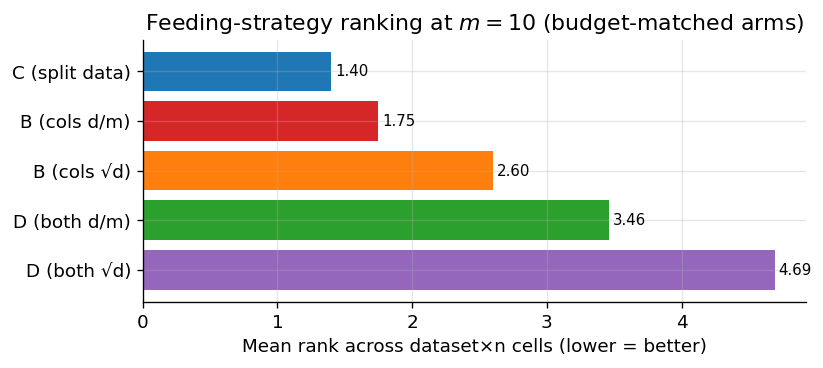

In [12]:
fig,ax=plt.subplots(figsize=(7,3.2))
r=ranking.sort_values("mean_rank")
ax.barh(r.index[::-1], r.mean_rank[::-1], color=[COLORS.get(x,"#555") for x in r.index[::-1]])
ax.set_xlabel("Mean rank across dataset×n cells (lower = better)")
ax.set_title("Feeding-strategy ranking at $m=10$ (budget-matched arms)")
for i,v in enumerate(r.mean_rank[::-1]): ax.text(v+0.03,i,f"{v:.2f}",va="center",fontsize=9)
plt.tight_layout(); plt.savefig(f"{FIG}/fig1_ranking.pdf",bbox_inches="tight"); plt.show()

### Fig 2 — Accuracy vs n per dataset at m=10 (regime split). Band = ±1 seed std.

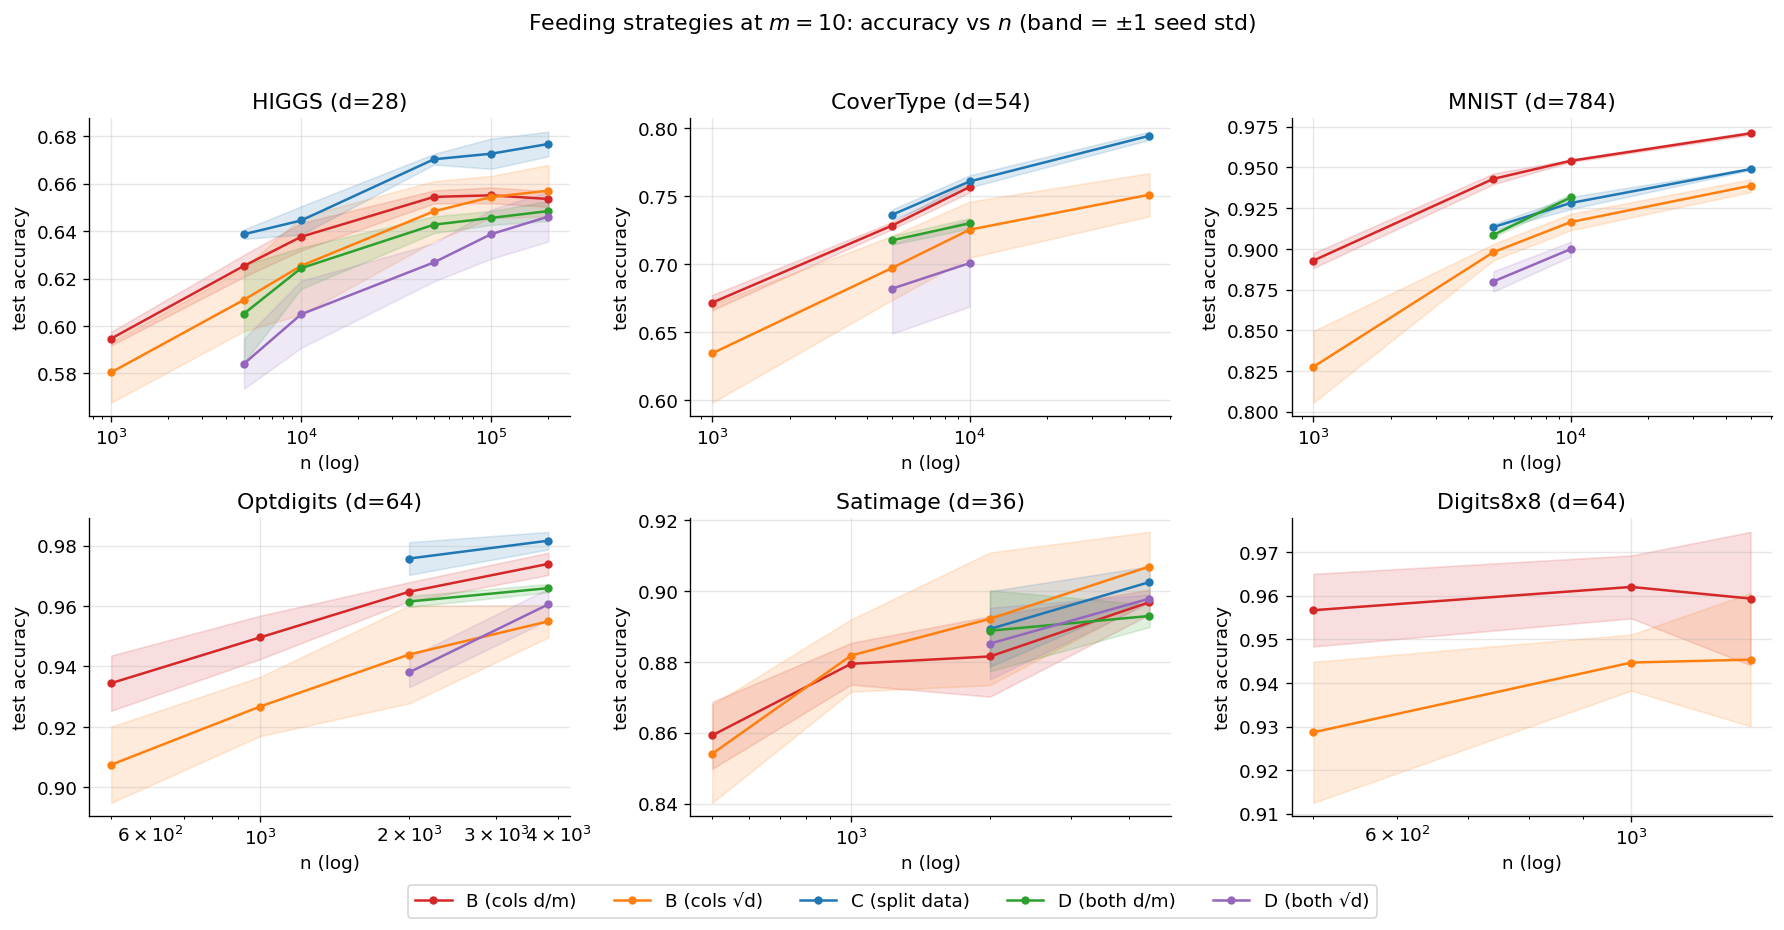

In [13]:
rk=bestL[(bestL.arm.isin(FEEDING_ARMS))&(bestL.m==10)]
ncol=3; nrow=int(np.ceil(len(DSORD)/ncol))
fig,axes=plt.subplots(nrow,ncol,figsize=(5*ncol,3.6*nrow),squeeze=False)
for k,ds in enumerate(DSORD):
    ax=axes[k//ncol][k%ncol]; s=rk[rk.dataset==ds]
    for lab,g in s.groupby("label"):
        g=g.sort_values("n_train")
        ax.plot(g.n_train,g.acc_mean,marker="o",ms=4,label=lab,color=COLORS.get(lab))
        ax.fill_between(g.n_train,g.acc_mean-g.acc_std,g.acc_mean+g.acc_std,alpha=0.15,color=COLORS.get(lab))
    ax.set_xscale("log"); ax.set_title(f"{ds} (d={int(df[df.dataset==ds].d.iloc[0])})")
    ax.set_xlabel("n (log)"); ax.set_ylabel("test accuracy")
for j in range(len(DSORD),nrow*ncol): axes[j//ncol][j%ncol].axis("off")
h,l=axes[0][0].get_legend_handles_labels()
fig.legend(h,l,loc="lower center",ncol=5,bbox_to_anchor=(0.5,-0.04))
fig.suptitle("Feeding strategies at $m=10$: accuracy vs $n$ (band = ±1 seed std)",y=1.02)
plt.tight_layout(); plt.savefig(f"{FIG}/fig2_regime_split.pdf",bbox_inches="tight"); plt.show()

### Fig 3 — m>1 gain over the m=1 baseline vs n

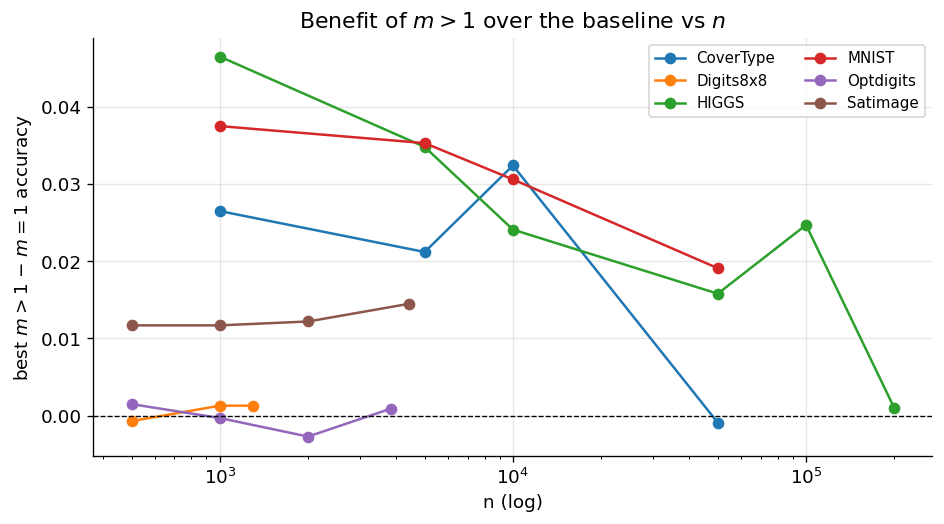

In [14]:
fig,ax=plt.subplots(figsize=(8,4.5))
for ds,g in gain.groupby("dataset"):
    g=g.sort_values("n"); ax.plot(g.n,g.gain,marker="o",label=ds)
ax.axhline(0,color="k",lw=0.8,ls="--"); ax.set_xscale("log")
ax.set_xlabel("n (log)"); ax.set_ylabel("best $m{>}1$ − $m{=}1$ accuracy")
ax.set_title("Benefit of $m>1$ over the baseline vs $n$"); ax.legend(fontsize=9,ncol=2)
plt.tight_layout(); plt.savefig(f"{FIG}/fig3_mgain.pdf",bbox_inches="tight"); plt.show()

### Fig 4 — The m=50 caveat (column-budget artifact, not a feeding verdict)

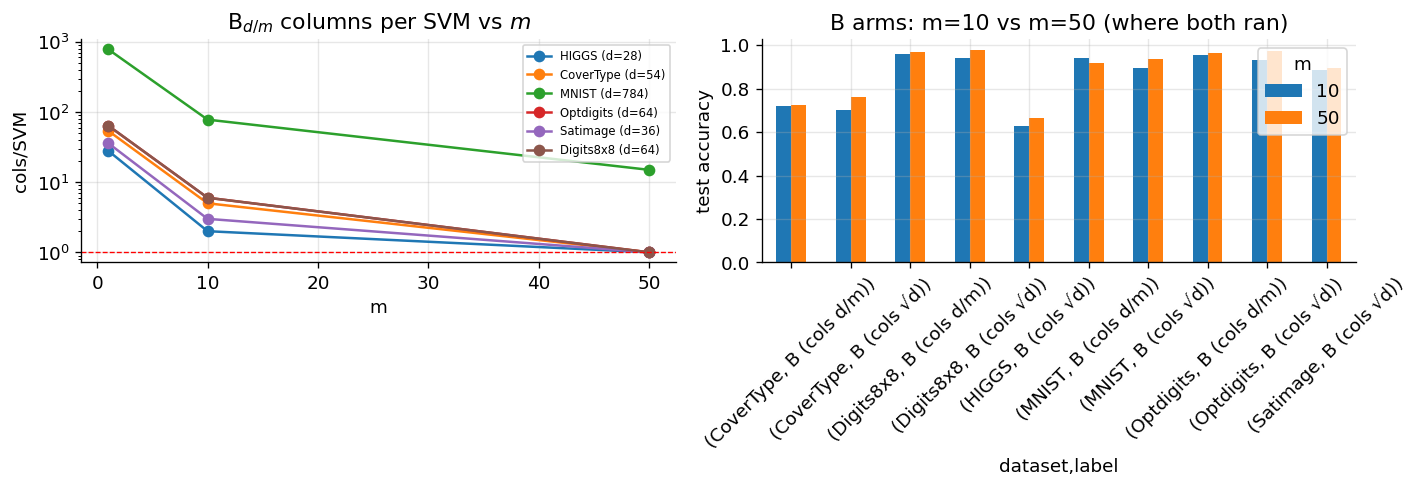

In [15]:
fig,(a1,a2)=plt.subplots(1,2,figsize=(12,4.2))
dd=df[["dataset","d"]].drop_duplicates().set_index("dataset")["d"]; ms=[1,10,50]
for ds in DSORD:
    a1.plot(ms,[max(1,int(dd[ds])//m) for m in ms],marker="o",label=f"{ds} (d={int(dd[ds])})")
a1.axhline(1,color="r",ls="--",lw=0.8); a1.set_yscale("log")
a1.set_title("B$_{d/m}$ columns per SVM vs $m$"); a1.set_xlabel("m"); a1.set_ylabel("cols/SVM"); a1.legend(fontsize=7)
sub=bestL[bestL.arm.isin(["B_in_dm","B_in_sqrt"])&bestL.m.isin([10,50])]
piv=sub.pivot_table(index=["dataset","label"],columns="m",values="acc_mean").dropna()
piv.plot.bar(ax=a2); a2.set_title("B arms: m=10 vs m=50 (where both ran)")
a2.set_ylabel("test accuracy"); a2.tick_params(axis="x",labelrotation=45)
plt.tight_layout(); plt.savefig(f"{FIG}/fig4_m50_caveat.pdf",bbox_inches="tight"); plt.show()

### Fig 5 — Depth effect L1→L2 by dataset

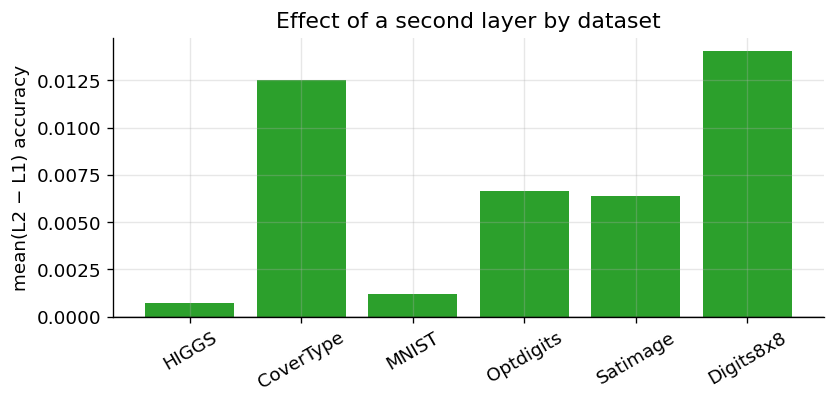

In [16]:
d2=cell[(cell.arm.isin(FEEDING_ARMS))&(cell.m>1)].pivot_table(index=["dataset","label","m","n_train"],columns="L",values="acc_mean")
if set([1,2]).issubset(d2.columns):
    d2=d2.dropna(subset=[1,2]); d2["dL"]=d2[2]-d2[1]
    dl=d2.groupby("dataset")["dL"].mean().reindex(DSORD)
    fig,ax=plt.subplots(figsize=(7,3.5))
    ax.bar(dl.index,dl.values,color=["#2ca02c" if v>0 else "#d62728" for v in dl.values])
    ax.axhline(0,color="k",lw=0.8); ax.set_ylabel("mean(L2 − L1) accuracy")
    ax.set_title("Effect of a second layer by dataset"); ax.tick_params(axis="x",labelrotation=30)
    plt.tight_layout(); plt.savefig(f"{FIG}/fig5_depth.pdf",bbox_inches="tight"); plt.show()

### Fig 6 — Decorrelation vs accuracy (feeding rows only, m>1)

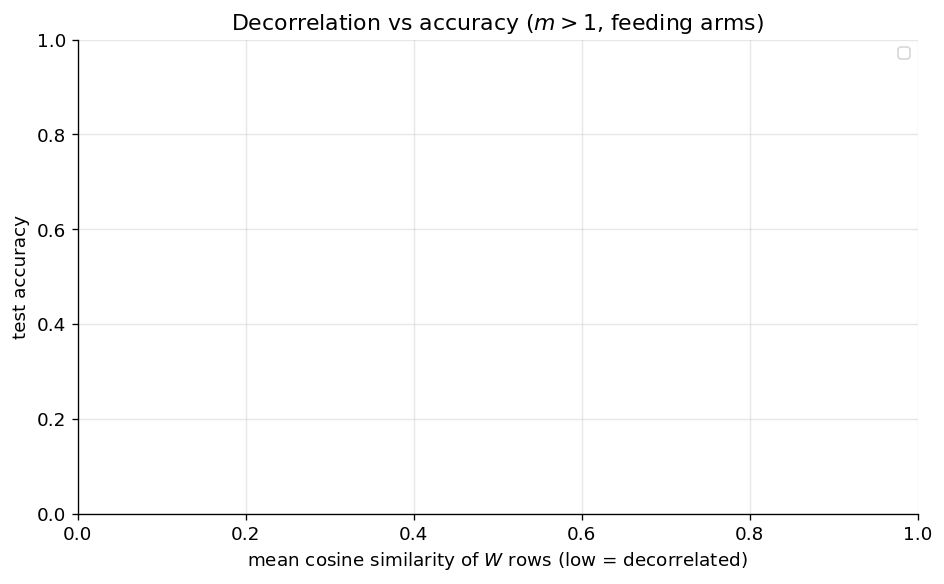

corr(cos, acc) by dataset:
figures: ['fig1_ranking.pdf', 'fig2_regime_split.pdf', 'fig3_mgain.pdf', 'fig4_m50_caveat.pdf', 'fig5_depth.pdf', 'fig6_decorrelation.pdf']


In [17]:
fdf=df[(df.source=="feeding")&(df.m>1)&df.cos.notna()]
fc=(fdf.groupby(["dataset","arm","m","L","n_train"]).agg(acc=("acc","mean"),cos=("cos","mean")).reset_index())
fig,ax=plt.subplots(figsize=(8,5))
for ds,g in fc.groupby("dataset"): ax.scatter(g.cos,g.acc,alpha=0.6,label=ds)
ax.set_xlabel("mean cosine similarity of $W$ rows (low = decorrelated)")
ax.set_ylabel("test accuracy"); ax.set_title("Decorrelation vs accuracy ($m>1$, feeding arms)"); ax.legend(fontsize=9)
plt.tight_layout(); plt.savefig(f"{FIG}/fig6_decorrelation.pdf",bbox_inches="tight"); plt.show()
print("corr(cos, acc) by dataset:")
for ds,g in fc.groupby("dataset"):
    if len(g)>3: print(f"  {ds:10s} r={g.cos.corr(g.acc):+.3f} (n={len(g)})")
print("figures:", sorted(os.listdir("figures")))